# Aprendizaje Profundo
## Tarea 3 - Redes Basadas en Atención
### Eduardo García


### Reconocimiento de comandos de voz
Entrena una red neuronal basada en bloques Transformer para el reconocimiento de comandos de voz usados en el conjunto Speech Commands. Se deberá representar los comandos de voz mediante espectrogramas Mel, Mel-Log o MFCCs y procesar estos como una secuencia de vectores columna.  

## Bibliotecas

In [5]:
# Bibliotecas 図書館
# funciones aleatorias
import random
# tomar n elementos de una secuencia
from itertools import islice as take
# gráficas
import matplotlib.patches as patches
import matplotlib.pyplot as plt
# arreglos multidimensionales
import numpy as np
# csv
import pandas as pd
# redes neuronales
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
# cargador de datos
from torch.utils.data import DataLoader, Dataset
# inspección de arquitectura
from torchinfo import summary
# barra de progreso
from tqdm.auto import trange
# imágenes
from PIL import Image

from einops import rearrange

# Por reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

In [6]:

LOGDIR = './logs/'
DC     = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device {DC}')

Device cuda:0


In [7]:
# audio
import librosa
import librosa.display

# redes audio
import torchaudio
import torchaudio.transforms as T


# redes neuronales
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

# barras de progreso
from tqdm.auto import trange

# Files
import os

## Datos

In [8]:
DATADIR = './'
download = not os.path.isdir('./SpeechCommands')
ds = SPEECHCOMMANDS(DATADIR, download=download)

100%|██████████| 2.26G/2.26G [00:24<00:00, 97.5MB/s]


In [9]:
# Tamaño de lote
BATCH_SIZE = 64

# Audio Params
SECS = 1
SAMPLE_RATE = 16000

# FFT Params
N_FFT = 400
HOP_LENGHT = N_FFT//2

# SpeechCommands classes
CLASSES = (
    'backward', 'bed', 'bird', 'cat', 'dog',
    'down', 'eight', 'five', 'follow', 'forward',
    'four', 'go', 'happy', 'house', 'learn',
    'left', 'marvin', 'nine', 'no', 'off',
    'on', 'one', 'right', 'seven', 'sheila',
    'six', 'stop', 'three', 'tree', 'two',
    'up', 'visual', 'wow', 'yes', 'zero'
)

NUM_CLASSES = len(CLASSES)
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASS_IDX)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


In [10]:

def identity(x):
  return x


def label2index(label):
  return CLASS_IDX[label]


class SPEECHCOMMANDS2(SPEECHCOMMANDS):

  def __init__(self, root, download=False, subset=None,
               waveform_tsfm=identity, label_tsfm=identity):
      
      super().__init__(root=root, download=download, subset=subset)
      self.time_mask = T.TimeMasking(time_mask_param=4000)
      self.waveform_tsfm = waveform_tsfm
      self.label_tsfm = label_tsfm
      
  def __getitem__(self, i):
    waveform, sample_rate, label, *_ = super().__getitem__(i)

    x = self.waveform_tsfm(waveform)
    y = self.label_tsfm(label)
    return x, y, label, sample_rate

In [11]:
class WaveformPadTruncate(nn.Module):

  def __init__(self, secs=SECS, sample_rate=SAMPLE_RATE):
    super().__init__()
    self.samples = secs * sample_rate

  def forward(self, waveform):
    samples = waveform.shape[1]

    if samples < self.samples:
      difference = self.samples - samples
      padding = torch.zeros(1, difference)
      waveform = torch.cat([waveform, padding], 1)

    elif samples > self.samples:
      start = np.random.randint(0, waveform.shape[1] - self.samples)
      # Devuelve un nuevo tensor que es una versión reducida del tensor de entrada.
      waveform = waveform.narrow(1, start, self.samples) # (dimension, start, length)

    return waveform


In [12]:
class RandomSilence(nn.Module):
  def __init__(self, ratio=.3):
    super().__init__()
    self.ratio = ratio

  def forward(self, waveform):
    samples = waveform.shape[1]
    # print(samples)
    silence_size = int(samples * self.ratio)
    # print(f'{silence_size = }')
    start = np.random.randint(0, samples - silence_size)
    # print(f'{start = }')
    waveform[:, start:start+silence_size] = 0.0

    return waveform
    

### Transformaciones

In [13]:
tr_ent = nn.Sequential(
  WaveformPadTruncate(),
  RandomSilence(),
  T.MFCC()
)

tr_val = nn.Sequential(
  WaveformPadTruncate(),
  # RandomSilence(),
  T.MFCC()
)

/home/ar/.local/lib/python3.8/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


### DataLoader

In [14]:
# creamos un Dataset
ds = SPEECHCOMMANDS2(
    # directorio de datos
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=tr_ent,
    #conjunto de entrenamiento
    subset="training",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_ent = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)


# creamos un Dataset
ds_val = SPEECHCOMMANDS2(
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=tr_val,
    #conjunto de validacion
    subset="validation",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_val = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)

In [15]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl_ent))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }, {sr=}')

x shape=torch.Size([64, 1, 40, 81]) dtype=torch.float32
y shape=torch.Size([64]) dtype=torch.int64
labels = ('on', 'up', 'eight', 'yes', 'no', 'up', 'yes', 'house', 'seven', 'left', 'left', 'six', 'go', 'on', 'three', 'forward', 'go', 'yes', 'seven', 'house', 'six', 'five', 'eight', 'go', 'three', 'tree', 'sheila', 'up', 'backward', 'right', 'happy', 'on', 'visual', 'backward', 'seven', 'off', 'four', 'visual', 'three', 'off', 'eight', 'bed', 'on', 'up', 'two', 'left', 'seven', 'up', 'yes', 'stop', 'sheila', 'cat', 'up', 'house', 'two', 'left', 'three', 'eight', 'nine', 'down', 'bird', 'tree', 'on', 'seven'), sr=tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 1600

In [19]:
def plot_mfcc(mfcc, sample_rate=16000, title=''):
    if isinstance(mfcc, torch.Tensor):
        mfcc = mfcc.numpy()

    # Plot the MFCCs
    plt.figure(figsize=(10, 4))
    plt.imshow(mfcc, aspect="auto", origin="lower", cmap="plasma")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"MFCC's de '{title}'")
    plt.xlabel("Time (frames)")
    plt.ylabel("MFCC Coefficients")
    plt.tight_layout()
    plt.show()

In [17]:
x.shape

torch.Size([64, 1, 40, 81])

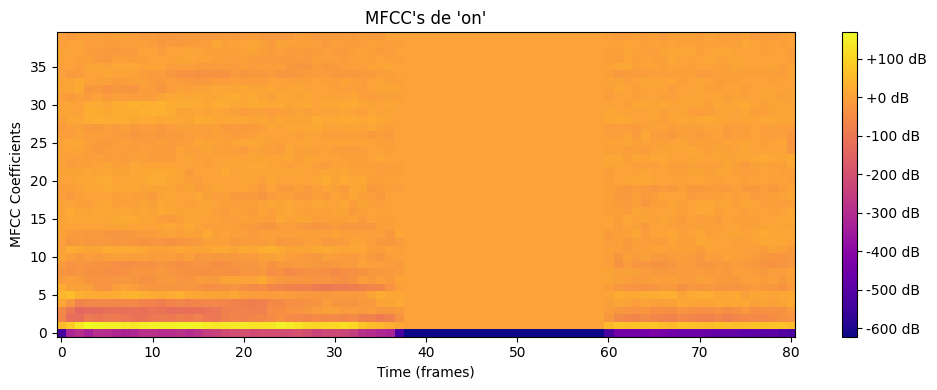

In [20]:
plot_mfcc(x[0].reshape(40, 81, 1), SAMPLE_RATE, labels[0])

## Modelo

In [21]:
class ProductoPuntoEscalado(nn.Module):
  def __init__(self,
               p_dropout = 0.0,
               masc = False):
    super(ProductoPuntoEscalado, self).__init__()
    self.masc = masc
    self.dropout = nn.Dropout(p_dropout)

  def forward(self, Q, K, V):
    # Obtenemos dimensiones
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    # Cambiamos la forma: [m, n_cabezas, l, d_k] -> [m * n_cabezas, l, d_k]
    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    # Q y K tienen forma [m * n_cabezas, l, d_k],
    # por lo que se transponen las dos últimas dimensiones de K
    # QK: [m * n_cabezas, l, l]
    QK = torch.bmm(Q, K.transpose(1, 2))

    # se escalan los valores QK
    QK_esc = QK / torch.math.sqrt(d_k)

    if self.masc:
      # Creamos una matriz triangular superior binaria (excluyendo la diagonal)
      masc = torch.triu(torch.ones((l, l), dtype = torch.bool, device = Q.device),
                    diagonal = 1)
      # Ponemos los valores de QK_esc en los que la máscara sea 1 a -inf
      QK_esc = QK_esc.masked_fill_(masc, -torch.inf)

    # mapas de atención: [m * n_cabezas, l, l] -> [m * n_cabezas, l, l]
    alfas = nn.functional.softmax(QK_esc, dim=-1)
    alfas = self.dropout(alfas) # Se agrega dropout de acuerdo al codigo de nanoGPT

    # vectores de salida y
    # alfas: [m * n_cabezas, l, l], V: [m * n_cabezas, l, d_v]
    # Y: [m * n_cabezas, l, d_v]
    Y = torch.bmm(alfas, V)

    # Cambiamos la forma: [m * n_cabezas, l, d_v] -> [m, n_cabezas, l, d_v]
    Y = Y.reshape(m, n_cabezas, l, d_v)

    # Cambiamos la forma: [m * n_cabezas, l, l] -> [m, n_cabezas, l, l]
    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas


class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               p_dropout = 0.0,
               masc = False):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo

    self.d_cabezas = self.d_modelo // self.n_cabezas

    self.ppe = ProductoPuntoEscalado(p_dropout=p_dropout, masc = masc)
    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma del tensor x
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Proyectamos vectores en x a Q, K, V
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    # Cambiamos la forma: [m * l, d_modelo] -> [m, l, n_cabezas, d_k]
    # d_k = d_v = self.d_modelo // self.n_cabezas
    Q = Q.reshape(m, l, self.n_cabezas, self.d_cabezas)
    K = K.reshape(m, l, self.n_cabezas, self.d_cabezas)
    V = V.reshape(m, l, self.n_cabezas, self.d_cabezas)

    # Transponemos el eje de las cabezas a la segunda posición del tensor y
    # creamos copia (con .contiguous()) para que esté almacenado en memoria de
    # forma contigua (.transpose() hace que ya no sea así).
    # [m, l, n_cabezas, d_k] -> [m, n_cabezas, l, d_k]
    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    # Calculamos el producto punto escalado con Q, K y V
    # Q, K: [m, n_cabezas, l, d_k], V:[m, n_cabezas, l, d_v]
    # Y: [m, n_cabezas, l, d_v], alfas: [m, n_cabezas, l, l]
    Y, alfas = self.ppe(Q, K, V)

    # Transponermos el eje de cabezas a la penúltima posición:
    # [m, n_cabezas, l, d_k] -> [m, l, n_cabezas, d_k]
    Y = Y.transpose(1, 2).contiguous()

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m, l, n_cabezas, d_k] -> [m * l, d_modelo]
    # d_modelo = n_cabezas * d_k
    Y = Y.reshape(m * l, self.d_modelo)

    # Proyectamos la vectores concatenados para obtener la salida
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Y = self.proy_sal(Y)

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m * l, d_modelo] -> [m, l, d_modelo]
    Y = Y.reshape(m, l, self.d_modelo)

    return Y, alfas

class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_ff):
    super(RedDensaPosicion, self).__init__()
    self.d_modelo = d_modelo
    self.d_ff = self.d_ff = d_ff if d_ff else 4*d_modelo
    self.densa1 = nn.Linear(self.d_modelo, self.d_ff)
    self.densa2 = nn.Linear(self.d_ff, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma: [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Pasamos el tensor redimensionado por la red densa
    # [m * l, d_modelo] -> [m * l, d_modelo]
    x = self.densa1(x)
    x = nn.functional.gelu(x)
    x = self.densa2(x)

    # Lo regresamos a su forma original
    # [m * l, d_modelo] -> [m, l, d_modelo]
    x = x.reshape(m, l, d_modelo)

    return x

class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp=None,
               p_dropout = 0.1,
              masc = False):
    super(BloqueTransformer, self).__init__()
    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                  n_cabezas = n_cabezas,
                                  p_dropout = p_dropout,
                                  masc = masc)
    self.norm1 = nn.LayerNorm(d_modelo)
    self.rp = RedDensaPosicion(d_modelo, d_rdp)
    self.norm2 = nn.LayerNorm(d_modelo)
    self.dropout1 = nn.Dropout(p_dropout)
    self.dropout2 = nn.Dropout(p_dropout)

  def forward(self, x):
    salidas_amc, alfas = self.amc(x)
    salidas_amc = self.dropout1(salidas_amc)
    salidas_amc = self.norm1(x + salidas_amc)

    salidas_rp = self.rp(salidas_amc)
    salidas_rp = self.dropout2(salidas_rp)

    return self.norm2(salidas_amc + salidas_rp)

In [22]:
class ViT(nn.Module):
    def __init__(self, img_size, patch_size, out_dim, d_modelo,
                 depth, n_cabezas, mlp_dim, dropout):
        super().__init__()
        self.d_modelo = d_modelo
        self.patch_size = patch_size
        # N = H*W/(P^2)
        # self.n_patches = (img_size // patch_size) ** 2
        self.n_patches = (img_size[0]//patch_size[0]) * (img_size[1]//patch_size[1])

        input_projection = 1*(patch_size[0] * patch_size[1]) # C*PP

        self.projection = nn.Linear(input_projection, d_modelo) #

        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.n_patches + 1, d_modelo))


        self.cls_token = nn.Parameter(torch.randn(1, 1, d_modelo))

        bloques = [BloqueTransformer(d_modelo,
                                     n_cabezas,
                                     mlp_dim,
                                     dropout,
                                     masc = False) for _ in range(depth)]
        self.transformer = nn.Sequential(*bloques)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(d_modelo),
            nn.Linear(d_modelo, out_dim),
        )

    def forward(self, x):
        B = x.shape[0]

        # Patches
        # N x (P^2 * C)
        # Donde:
        # N = HW/P^2

        #img_patches0 = x.reshape(B, self.n_patches, int((patch_size*patch_size)*C))

        img_patches = rearrange(x,
                        'b c (patch_x x) (patch_y y) -> b (x y) (patch_x patch_y c)',
                        patch_x=self.patch_size[0], patch_y=self.patch_size[1])

        # Linear Projection
        x = self.projection(img_patches)

        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat((cls_token, x), dim=1)
        x += self.pos_embedding

        x = self.transformer(x)
        x = x[:, 0, :]
        return self.mlp_head(x)

In [23]:
IMG_SIZE = (40, 81)
PATCH_SIZE = (40,1)

In [24]:
patch_size = PATCH_SIZE
out_dim = len(CLASSES)
d_modelo = 64
depth = 3

n_cabezas = 4
mlp_dim = 256
dropout = 0.5

vit = ViT(IMG_SIZE, patch_size, out_dim, d_modelo, depth, n_cabezas, mlp_dim, dropout)


## Entrenamiento

In [25]:
def train_epoch(dl, model, opt, device):
    """Entrena una época"""
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    # entrenamiento de una época
    for batch in dl:
        x = batch[0].to(device)
        y_true = batch[1].to(device)
        # computamos logits
        y_lgts = model(x)

        # Para obtener el Accuracy:
        # computamos las probabilidades
        y_prob = F.softmax(y_lgts, 1)
        # obtenemos la clase predicha
        y_pred = torch.argmax(y_prob, 1)

        # computamos la pérdida
        loss = F.cross_entropy(y_lgts, y_true)

        # computamos la exactitud
        acc = (y_true == y_pred).type(torch.float32).mean()

        # vaciamos los gradientes
        opt.zero_grad()
        # retropropagamos
        loss.backward()

        # actualizamos parámetros
        opt.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    trn_loss = epoch_loss / len(dl)
    trn_acc = epoch_acc / len(dl)

    return trn_loss, trn_acc

def eval_epoch(dl, model, device, num_batches=None):
    """Evalua una época"""

    # Modelo en modo de evaluación
    # Congelar las estadísticas σ y μ
    model.eval()

    # evitamos que se registren las operaciones
    # en la gráfica de cómputo
    with torch.no_grad():

        losses, accs = [], []
        # validación de la época con num_batches
        # si num_batches==None, se usan todos los lotes
        for batch in take(dl, num_batches):
            x = batch[0].to(device)
            y_true = batch[1].to(device)
            # hacemos inferencia para obtener los logits
            y_lgts = model(x)
            # computamos las probabilidades
            y_prob = F.softmax(y_lgts, 1)
            # obtenemos la clase predicha
            y_pred = torch.argmax(y_prob, 1)

            # computamos la pérdida
            loss = F.cross_entropy(y_lgts, y_true)
            # computamos la exactitud
            acc = (y_true == y_pred).type(torch.float32).mean()

            # guardamos históricos
            losses.append(loss.item())
            accs.append(acc.item())

        loss = np.mean(losses)
        acc = np.mean(accs)

        return loss, acc

def train(model, trn_dl, val_dl, epochs,
          trn_batches=None, val_batches=None):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    # optimizador
    opt = optim.Adam(model.parameters(), lr=0.0001)

    # usamos GPU si está disponible
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # movemos a dispositivo
    model.to(device)

    # ciclo de entrenamiento
    for epoch in trange(epochs):

        # entrenamos la época
        trn_loss , trn_acc = train_epoch(trn_dl, model, opt, device)
        # evaluamos la época en validación
        val_loss, val_acc = eval_epoch(val_dl, model, device, val_batches)

        train_losses.append(trn_loss)
        val_losses.append(val_loss)

        train_accs.append(trn_acc)
        val_accs.append(val_acc)

        print(f'\nEpoch {epoch}: Train loss: {trn_loss:4f} Train Accuracy: {trn_acc:4f}')
        print(f'Val loss: {val_loss:4f} Val Accuracy: {val_acc:4f}')

    return train_losses, val_losses, train_accs, val_accs

In [26]:
model = vit
train_losses, val_losses, train_accs, val_accs = train(model, dl_ent, dl_val, epochs=15)

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 0: Train loss: 3.216707 Train Accuracy: 0.107324
Val loss: 2.816809 Val Accuracy: 0.197686

Epoch 1: Train loss: 2.739658 Train Accuracy: 0.217794
Val loss: 2.414779 Val Accuracy: 0.299866

Epoch 2: Train loss: 2.481348 Train Accuracy: 0.282068
Val loss: 2.206307 Val Accuracy: 0.358289

Epoch 3: Train loss: 2.345558 Train Accuracy: 0.324252
Val loss: 2.093331 Val Accuracy: 0.393056

Epoch 4: Train loss: 2.240621 Train Accuracy: 0.352250
Val loss: 1.976013 Val Accuracy: 0.427830

Epoch 5: Train loss: 2.156622 Train Accuracy: 0.377225
Val loss: 1.905238 Val Accuracy: 0.446919

Epoch 6: Train loss: 2.084820 Train Accuracy: 0.398665
Val loss: 1.855233 Val Accuracy: 0.461783

Epoch 7: Train loss: 2.035620 Train Accuracy: 0.409482
Val loss: 1.790728 Val Accuracy: 0.481109

Epoch 8: Train loss: 1.992352 Train Accuracy: 0.421384
Val loss: 1.745469 Val Accuracy: 0.489586

Epoch 9: Train loss: 1.952620 Train Accuracy: 0.435293
Val loss: 1.720459 Val Accuracy: 0.497181

Epoch 10: Train los

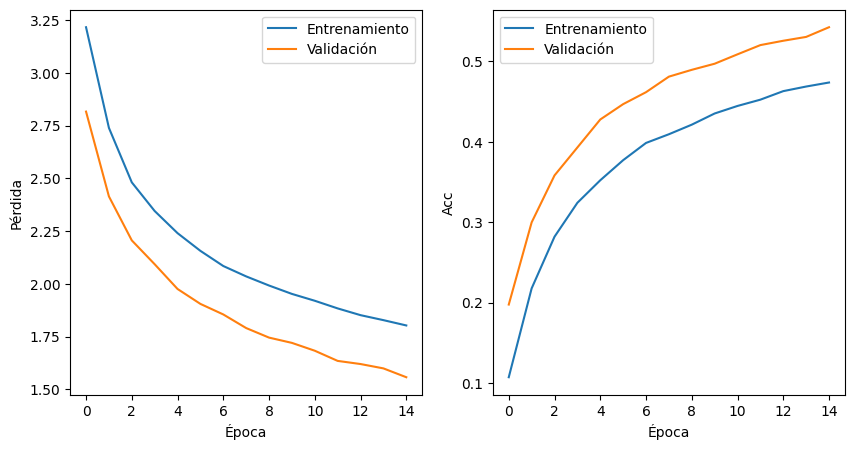

In [27]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(train_losses, label='Entrenamiento')
axs[0].plot(val_losses, label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(train_accs, label='Entrenamiento')
axs[1].plot(val_accs, label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acc')
axs[1].legend()
plt.show()

## Resultados

El tiempo de entrenamiento fue de aproximadamente 3 horas, lo cual es algo relativamente considerable. Sería conveniente ir bajando la cantidad de MFCCs Y ver qué tanto impacta la reducción de coeficientes. En este caso los dejé por default, entonces son 40. Pero en la libreta y en alguna otra literatura, con 14 es suficiente para lograr hacer una clasificación con métodos clásicos como lo es KNN. Aunque .5 acc para 15 épocas creo que es un resultado no tan malo.